# Docling Enhanced Extraction Test

Testing Docling's full extraction pipeline — tables, figures, formulas, charts — on local research paper PDFs.
**VlmPipeline is excluded** (hardware limitation).


## 1. Install & Import Dependencies


In [19]:
import subprocess, sys

# Install docling if not present
try:
    import docling
    # print(f"docling already installed: {docling.__version__}")
    
except ImportError:
    print("Installing docling...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "docling", "-q"])
    print("docling installed successfully")


In [20]:
import time
import json
from pathlib import Path

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, AcceleratorOptions, AcceleratorDevice

print("All imports successful.")


All imports successful.


## 2. Configure PDF Pipeline Options

Enabling table structure, figure image extraction, and formula enrichment.
`images_scale=2.0` improves image resolution.

Running on **CPU** via `AcceleratorOptions(device=AcceleratorDevice.CPU)` — set `num_threads` to match your core count.
**VlmPipeline excluded** — too expensive for this hardware.


In [21]:
# Force CPU execution — no GPU/MPS required
# accelerator_options = AcceleratorOptions(
#     num_threads=4,                    # Adjust to your CPU core count
#     device=AcceleratorDevice.CPU,
# )

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,          # Extract tables with full row/column structure
    generate_picture_images=True,     # Extract figures as actual images
    # do_formula_enrichment=True,    ?   # Enrich formulas (LaTeX-level output)
    images_scale=2.0,                 # 2x resolution for extracted images
    # accelerator_options=accelerator_options,
    # VlmPipeline intentionally excluded — not feasible on this hardware
)

print("Pipeline options configured:")
# print(f"  device                 = {accelerator_options.device}")
# print(f"  num_threads            = {accelerator_options.num_threads}")
print(f"  do_table_structure     = {pipeline_options.do_table_structure}")
print(f"  generate_picture_images= {pipeline_options.generate_picture_images}")
print(f"  do_formula_enrichment  = {pipeline_options.do_formula_enrichment}")
print(f"  images_scale           = {pipeline_options.images_scale}")


Pipeline options configured:
  do_table_structure     = True
  generate_picture_images= True
  do_formula_enrichment  = False
  images_scale           = 2.0


## 3. Convert PDF Document

Using `Gated Attention.pdf` from the `input/` folder. Timing the conversion to gauge hardware performance.


In [22]:
# Point to a PDF in the input/ folder (change the filename as needed)
PDF_PATH = Path("../input/MemGPT.pdf")

assert PDF_PATH.exists(), f"PDF not found: {PDF_PATH.resolve()}"

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print(f"Converting: {PDF_PATH.name}")
t_start = time.perf_counter()
result = converter.convert(str(PDF_PATH))
elapsed = time.perf_counter() - t_start

doc = result.document
print(f"\nConversion completed in {elapsed:.2f}s")
print(f"Pages       : {result.document.num_pages()}")
print(f"Text blocks : {len(list(doc.texts))}")
print(f"Tables      : {len(list(doc.tables))}")
print(f"Figures     : {len(list(doc.pictures))}")


[INFO] 2026-05-10 18:37:39,875 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-10 18:37:39,886 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-05-10 18:37:39,887 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx


[INFO] 2026-05-10 18:37:39,969 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-10 18:37:39,972 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-05-10 18:37:39,972 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-05-10 18:37:40,014 [RapidOCR] base.py:22: Using engine_name: onnxruntime


Converting: MemGPT.pdf


[INFO] 2026-05-10 18:37:40,035 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx
[INFO] 2026-05-10 18:37:40,036 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx



Conversion completed in 8.06s
Pages       : 13
Text blocks : 343
Tables      : 3
Figures     : 8


In [23]:
doc.tables


[TableItem(self_ref='#/tables/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TABLE: 'table'>, prov=[ProvenanceItem(page_no=4, bbox=BoundingBox(l=58.15658950805664, t=656.5069274902344, r=286.7086181640625, b=531.8681030273438, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], source=[], comments=[], captions=[], references=[], footnotes=[], image=None, data=TableData(table_cells=[TableCell(bbox=BoundingBox(l=208.304, t=139.265, r=273.059, b=147.32600000000002, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), row_span=1, col_span=2, start_row_offset_idx=0, end_row_offset_idx=1, start_col_offset_idx=2, end_col_offset_idx=4, text='Context Window', column_header=True, row_header=False, row_section=False, fillable=False), TableCell(bbox=BoundingBox(l=64.641, t=149.22699999999998, r=142.976, b=157.288, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), row_span=1, col_span=1, start_row_offset_idx=1,

In [24]:
doc.texts

[TextItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, label=<DocItemLabel.PAGE_HEADER: 'page_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=18.34, t=632.0, r=36.34, b=232.0, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 40))], source=[], comments=[], orig='arXiv:2310.08560v2  [cs.AI]  12 Feb 2024', text='arXiv:2310.08560v2  [cs.AI]  12 Feb 2024', formatting=None, hyperlink=None),
 SectionHeaderItem(self_ref='#/texts/1', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=148.345, t=700.976, r=448.539, b=688.079, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 41))], source=[], comments=[], orig='MemGPT: Towards LLMs as Operating Systems', text='MemGPT: Towards LLMs as Operating Systems', formatting=

## 4. Export to Multiple Formats

Docling supports JSON, Markdown, HTML, and plain text exports. JSON is the most complete — it preserves the full element hierarchy.


In [25]:
stem = PDF_PATH.stem  # e.g. "Gated Attention"

# --- JSON (most complete) ---
# DoclingDocument is a Pydantic model — use model_dump_json() instead of export_to_json()
json_output = doc.model_dump_json(indent=2)
json_path = Path(f"{stem}_docling.json")
json_path.write_text(json_output, encoding="utf-8")
print(f"JSON saved  -> {json_path}  ({json_path.stat().st_size / 1024:.1f} KB)")
print("Preview (first 400 chars):")
print(json_output[:400])
print("...")


JSON saved  -> MemGPT_docling.json  (1013.5 KB)
Preview (first 400 chars):
{
  "schema_name": "DoclingDocument",
  "version": "1.9.0",
  "name": "MemGPT",
  "origin": {
    "mimetype": "application/pdf",
    "binary_hash": 5616105910082953952,
    "filename": "MemGPT.pdf",
    "uri": null
  },
  "furniture": {
    "self_ref": "#/furniture",
    "parent": null,
    "children": [],
    "content_layer": "furniture",
    "meta": null,
    "name": "_root_",
    "label": "unsp
...


In [26]:
# --- Markdown ---
md_output = doc.export_to_markdown()
md_path = Path(f"{stem}_docling.md")
md_path.write_text(md_output, encoding="utf-8")
print(f"Markdown saved -> {md_path}")
print("\nPreview (first 600 chars):")
print(md_output[:600])
print("...")


Markdown saved -> MemGPT_docling.md

Preview (first 600 chars):
## MemGPT: Towards LLMs as Operating Systems

Charles Packer 1 Sarah Wooders 1 Kevin Lin 1 Vivian Fang 1 Shishir G. Patil 1 Ion Stoica 1 Joseph E. Gonzalez 1

## Abstract

Large language models (LLMs) have revolutionized AI, but are constrained by limited context windows, hindering their utility in tasks like extended conversations and document analysis. To enable using context beyond limited context windows, we propose virtual context management , a technique drawing inspiration from hierarchical memory systems in traditional operating systems which provide the illusion of an extended virtual
...


In [27]:
# --- HTML ---
html_output = doc.export_to_html()
html_path = Path(f"{stem}_docling.html")
html_path.write_text(html_output, encoding="utf-8")
print(f"HTML saved  -> {html_path}")

# --- Plain text ---
text_output = doc.export_to_text()
txt_path = Path(f"{stem}_docling.txt")
txt_path.write_text(text_output, encoding="utf-8")
print(f"Text saved  -> {txt_path}")
print("\nPlain text preview (first 400 chars):")
print(text_output[:400])


Parameter `strict_text` has been deprecated and will be ignored.


HTML saved  -> MemGPT_docling.html
Text saved  -> MemGPT_docling.txt

Plain text preview (first 400 chars):
## MemGPT: Towards LLMs as Operating Systems

Charles Packer 1 Sarah Wooders 1 Kevin Lin 1 Vivian Fang 1 Shishir G. Patil 1 Ion Stoica 1 Joseph E. Gonzalez 1

## Abstract

Large language models (LLMs) have revolutionized AI, but are constrained by limited context windows, hindering their utility in tasks like extended conversations and document analysis. To enable using context beyond limited cont


## 5. Extract & Inspect Text Blocks and Headings


In [28]:
from docling_core.types.doc import DocItemLabel

# Separate headings from body text
headings = []
paragraphs = []
list_items = []

for item, _level in doc.iterate_items():
    label = str(item.label).lower()
    if "section_header" in label or "title" in label:
        headings.append((item.text, _level))
    elif "list_item" in label:
        list_items.append(item.text)
    elif "text" in label:
        paragraphs.append(item.text)

print("=" * 62)
print("SECTION HIERARCHY")
print("=" * 62)
for text, lvl in headings:
    indent = "  " * max(0, lvl - 1)
    print(f"{indent}- {text}")

print(f"\nTotal paragraphs : {len(paragraphs)}")
print(f"Total list items : {len(list_items)}")


SECTION HIERARCHY
- MemGPT: Towards LLMs as Operating Systems
- Abstract
- 1. Introduction
- 2. MemGPT (MemoryGPT)
- 2.1. Main context ( prompt tokens )
- 2.2. Queue Manager
- LLM Finite Context Window (e.g. 8k tokens)
- 2.3. Function executor (handling of completion tokens )
- 2.4. Control flow and function chaining
- 3. Experiments
- 3.1. MemGPT for conversational agents
- 3.1.1. DEEP MEMORY RETRIEVAL TASK (CONSISTENCY).
- 3.1.2. CONVERSATION OPENER TASK (ENGAGEMENT).
- 3.2. MemGPT for document analysis
- 3.2.1. MULTI-DOCUMENT QUESTION-ANSWERING.
- 3.2.2. NESTED KEY-VALUE RETRIEVAL (KV).
- 4. Related Work
- 5. Conclusion
- References
- 6. Appendix
- 6.1. Prompts and instructions
- 6.1.1. MEMGPT INSTRUCTIONS (DMR)
- 6.1.2. LLM JUDGE (DMR / OPENER)
- 6.1.3. SELF-INSTRUCT DMR DATASET GENERATION
- 6.1.4. DOCUMENT ANALYSIS INSTRUCTIONS
- Questions were provided to MemGPT with the following prompt:
- For baselines, the following prompt along with a retrieved list of documents was provided:

In [29]:
# Preview first 5 paragraphs
print("First 5 paragraphs:")
print("-" * 62)
for i, p in enumerate(paragraphs[:5], 1):
    print(f"[{i}] {p[:200]}")
    print()


First 5 paragraphs:
--------------------------------------------------------------
[1] Charles Packer 1 Sarah Wooders 1 Kevin Lin 1 Vivian Fang 1 Shishir G. Patil 1 Ion Stoica 1 Joseph E. Gonzalez 1

[2] Large language models (LLMs) have revolutionized AI, but are constrained by limited context windows, hindering their utility in tasks like extended conversations and document analysis. To enable using

[3] In recent years, large language models (LLMs) and their underlying transformer architecture (Vaswani et al., 2017; Devlin et al., 2018; Brown et al., 2020; Ouyang et al., 2022) have become the corners

[4] LLMs can only support a few dozen back-and-forth messages or reason about a short document before exceeding their maximum input length (Touvron et al., 2023).

[5] Directly extending the context length of transformers incurs a quadratic increase in computational time and memory cost due to the transformer architecture's self-attention mechanism, making the desig



## 6. Extract & Inspect Tables


In [30]:
import pandas as pd

tables = list(doc.tables)
print(f"Total tables found: {len(tables)}")
print("=" * 62)

for i, table in enumerate(tables, 1):
    caption = table.caption_text(doc) or "(no caption)"
    page = table.prov[0].page_no if table.prov else "?"
    print(f"\nTable {i} — Page {page}")
    print(f"Caption: {caption}")

    # Export to DataFrame for easy inspection
    try:
        df = table.export_to_dataframe()
        print(f"Shape  : {df.shape[0]} rows x {df.shape[1]} cols")
        display(df)
    except Exception as e:
        print(f"  Could not export to DataFrame: {e}")


Total tables found: 3

Table 1 — Page 4
Caption: (no caption)


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


Shape  : 10 rows x 4 cols


,Model / API name Showing 3 of 3,Open? results (page 1/1): yeah,Context Window.Tokens,Context Window.∗ Messages
0,Llama (1) [01/24/2024] [01/14/2024],"✓ 'lol six flags', 'i love six flags been","2k like 100 times',",20
1,Llama 2 [10/12/2023],✓ 'james and I actually,4k first met at six,60 flags'
2,GPT-3.5 Turbo (release),✗,4k,60
3,Mistral 7B Did with,✓ James? It's so,8k cute how both,140 met there!
4,GPT-4 (release) you go,✗,8k,140
5,GPT-3.5 Turbo,✗,16k,300
6,GPT-4,✗,32k,∼ 600
7,Claude 2,✗,100k,∼ 2000
8,GPT-4 Turbo,✗,128k,∼ 2600
9,Yi-34B-200k,✓,200k,∼ 4000


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Table 2 — Page 5
Caption: Table 2. Deep memory retrieval (DMR) performance. In this task, the agent is asked a specific question about a topic discussed in a prior conversation (sessions 1-5). The agent's response is scored against the gold answer. MemGPT significantly outperforms the fixed-context baselines.
Shape  : 6 rows x 3 cols


,Model,Accuracy ⇑,ROUGE-L (R) ⇑
0,GPT-3.5 Turbo,38.7%,0.394
1,+ MemGPT,66.9%,0.629
2,GPT-4,32.1%,0.296
3,+ MemGPT,92.5%,0.814
4,GPT-4 Turbo,35.3%,0.359
5,+ MemGPT,93.4%,0.827


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Table 3 — Page 5
Caption: Table 3. Conversation opener performance. The agent's conversation opener is evaluated using similarity scores to the gold persona labels (SIM-1/3) and to the human-created opener (SIMH). MemGPT is able to exceed the performance of the humancreated conversation opener with a variety of underlying models.
Shape  : 4 rows x 4 cols


,Method,⇑ SIM-1,SIM-3,SIM-H
0,Human,0.800,0.800,1.000
1,GPT-3.5 Turbo,0.830,0.812,0.817
2,GPT-4,0.868,0.843,0.773
3,GPT-4 Turbo,0.857,0.828,0.767


## 7. Extract & Inspect Figures

`generate_picture_images=True` means each figure has an actual `PIL.Image` attached. Displaying them inline here.


Total figures found: 8

Figure 1 — Page 2
Caption: Figure 1. MemGPT (left) writes data to persistent memory after it receives a system alert about limited context space.


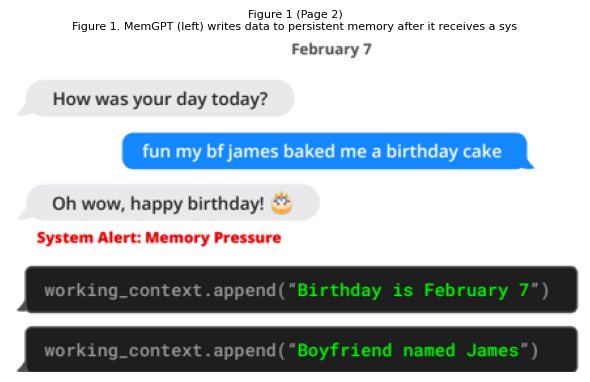


Figure 2 — Page 2
Caption: (no caption)


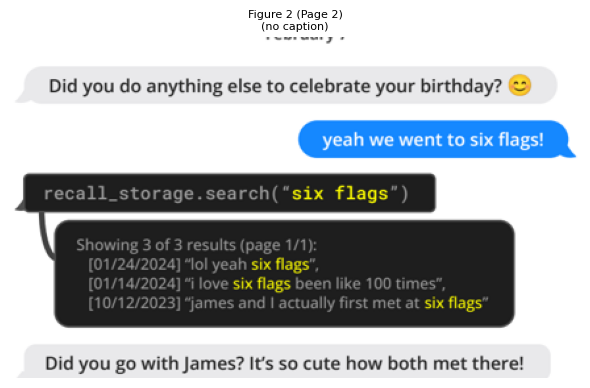


Figure 3 — Page 3
Caption: Figure 3. In MemGPT, a fixed-context LLM processor is augmented with a hierarchical memory system and functions that let


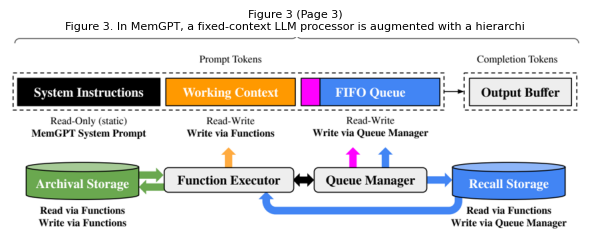


Figure 4 — Page 4
Caption: Figure 4. An example conversation snippet where MemGPT (left) updates stored information. Here the information is stored


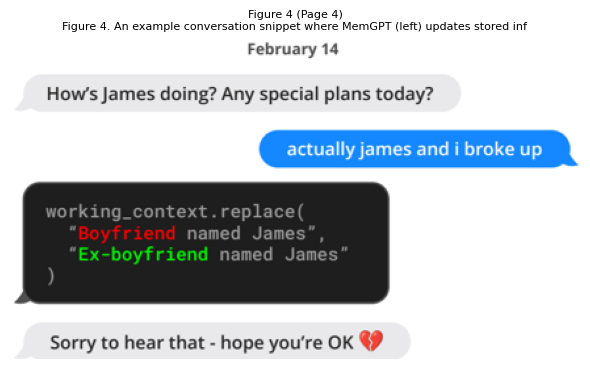


Figure 5 — Page 6
Caption: Figure 5. Document QA task performance. MemGPT's performance is unaffected by increased context length. Methods such as 


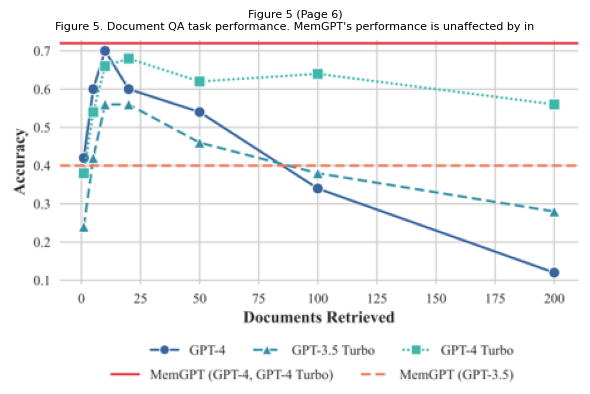


Figure 6 — Page 6
Caption: (no caption)


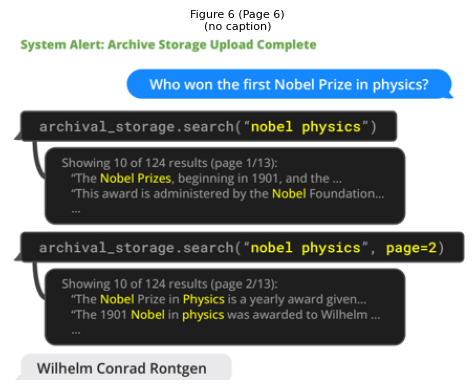


Figure 7 — Page 7
Caption: (no caption)


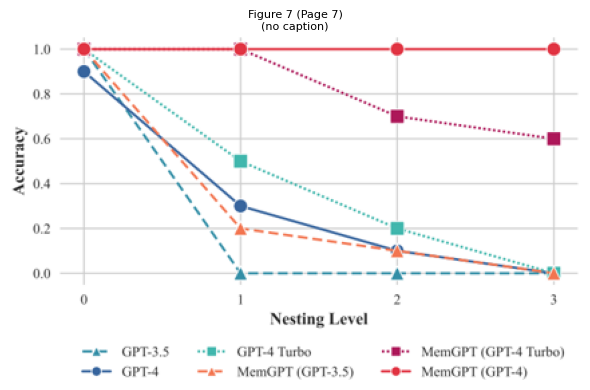


Figure 8 — Page 7
Caption: Figure 8. An example of MemGPT (left) solving the nested KV task (UUIDs shortened for readability). In this particular e


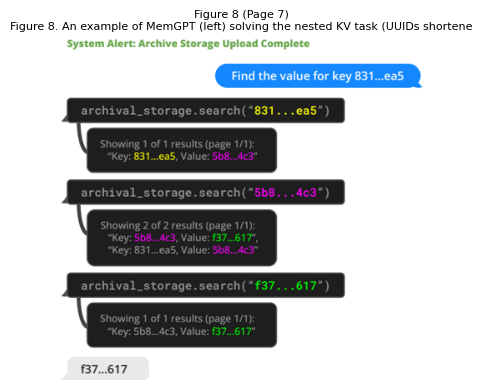

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pictures = list(doc.pictures)
print(f"Total figures found: {len(pictures)}")

for i, pic in enumerate(pictures, 1):
    caption = pic.caption_text(doc) or "(no caption)"
    page = pic.prov[0].page_no if pic.prov else "?"
    print(f"\nFigure {i} — Page {page}")
    print(f"Caption: {caption[:120]}")

    # get_image() returns a PIL Image if generate_picture_images=True
    try:
        pil_img = pic.get_image(doc)
        if pil_img:
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.imshow(pil_img)
            ax.set_title(f"Figure {i} (Page {page})\n{caption[:80]}", fontsize=8)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            print("  (image data not available)")
    except Exception as e:
        print(f"  Could not display image: {e}")


## 10. Traverse JSON Hierarchy Programmatically

Load the saved JSON and recursively walk the entire element tree to count and categorise every element type.


In [32]:
from collections import defaultdict

# Load the JSON export we saved earlier
with open(json_path, "r", encoding="utf-8") as f:
    doc_json = json.load(f)

# ── helpers ────────────────────────────────────────────────────────────────
def walk(node: dict | list, counts: dict, depth: int = 0) -> None:
    """Recursively walk the Docling JSON structure counting element labels."""
    if isinstance(node, dict):
        label = node.get("label") or node.get("type")
        if label:
            counts[label] += 1
        for v in node.values():
            walk(v, counts, depth + 1)
    elif isinstance(node, list):
        for item in node:
            walk(item, counts, depth)


def summarise(doc_json: dict) -> dict:
    counts = defaultdict(int)
    walk(doc_json, counts)
    return dict(sorted(counts.items(), key=lambda x: -x[1]))


# ── run ─────────────────────────────────────────────────────────────────────
element_counts = summarise(doc_json)

print(f"{'Element Label':<30} {'Count':>6}")
print("-" * 38)
for label, count in element_counts.items():
    print(f"{label:<30} {count:>6}")


Element Label                   Count
--------------------------------------
text                              234
list_item                          36
section_header                     31
page_header                        13
page_footer                        13
caption                            10
picture                             8
code                                5
table                               3
unspecified                         2
list                                2
key_value_area                      1
footnote                            1


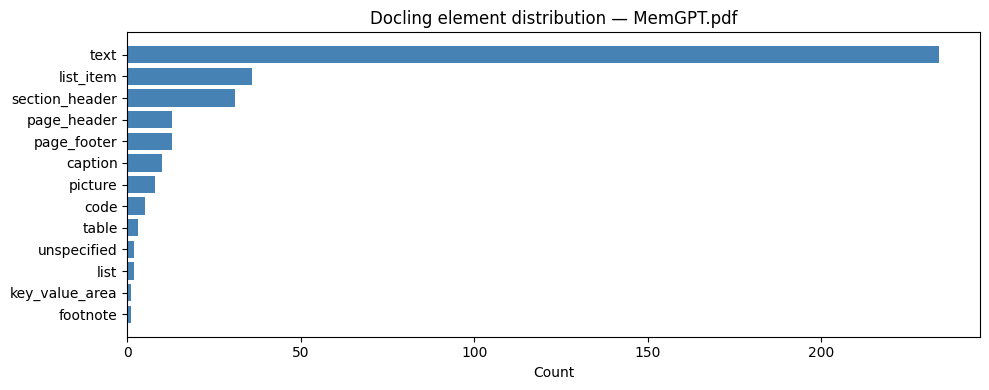

In [33]:
# Bar chart of element distribution
labels = list(element_counts.keys())[:20]       # Top 20
counts_vals = [element_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(labels[::-1], counts_vals[::-1], color="steelblue")
ax.set_xlabel("Count")
ax.set_title(f"Docling element distribution — {PDF_PATH.name}")
plt.tight_layout()
plt.show()


In [34]:
## 11. Annotate PDF with Colored Bounding Boxes

# Draw category-colored borders directly on the PDF pages and save the result.

# | Category | Color |
# |---|---|
# | Text / paragraph | Green |
# | Section header / title | Blue |
# | Table | Orange |
# | Figure / picture | Yellow |
# | Formula / equation | Red |
# | List item | Purple |


In [35]:
import fitz  # PyMuPDF

# ── Color map (RGB 0-1 floats) ─────────────────────────────────────────────
COLOR_MAP = {
    "text":           (0.13, 0.69, 0.30),   # green
    "section_header": (0.20, 0.47, 0.90),   # blue
    "title":          (0.20, 0.47, 0.90),   # blue
    "table":          (0.96, 0.49, 0.00),   # orange
    "picture":        (0.95, 0.85, 0.00),   # yellow
    "formula":        (0.90, 0.10, 0.10),   # red
    "equation":       (0.90, 0.10, 0.10),   # red
    "list_item":      (0.60, 0.10, 0.80),   # purple
}
DEFAULT_COLOR = (0.55, 0.55, 0.55)          # grey for anything else

def docling_to_fitz_rect(bbox, page_height: float) -> fitz.Rect:
    """Convert Docling BOTTOMLEFT-origin bbox → PyMuPDF TOPLEFT-origin Rect."""
    return fitz.Rect(
        bbox.l,
        page_height - bbox.t,
        bbox.r,
        page_height - bbox.b,
    )

# ── Open source PDF ────────────────────────────────────────────────────────
pdf_doc = fitz.open(str(PDF_PATH))

# Cache page heights (avoids repeated attribute access)
page_heights = {i: pdf_doc[i].rect.height for i in range(len(pdf_doc))}

highlight_counts = defaultdict(int)

# ── 1. Text / headings / list items / formulas ────────────────────────────
for item, _level in doc.iterate_items():
    label = str(item.label).lower()
    color = COLOR_MAP.get(label, DEFAULT_COLOR)

    if not item.prov:
        continue
    for prov in item.prov:
        page_no = prov.page_no - 1          # Docling is 1-indexed
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        page = pdf_doc[page_no]
        page.draw_rect(rect, color=color, width=1.2)
        highlight_counts[label] += 1

# ── 2. Tables ─────────────────────────────────────────────────────────────
color = COLOR_MAP["table"]
for table in doc.tables:
    if not table.prov:
        continue
    for prov in table.prov:
        page_no = prov.page_no - 1
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        pdf_doc[page_no].draw_rect(rect, color=color, width=2.0)
        highlight_counts["table"] += 1

# ── 3. Figures ────────────────────────────────────────────────────────────
color = COLOR_MAP["picture"]
for pic in doc.pictures:
    if not pic.prov:
        continue
    for prov in pic.prov:
        page_no = prov.page_no - 1
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        pdf_doc[page_no].draw_rect(rect, color=color, width=2.0)
        highlight_counts["picture"] += 1

# ── Save ──────────────────────────────────────────────────────────────────
output_pdf = Path(f"{stem}_annotated.pdf")
pdf_doc.save(str(output_pdf))
pdf_doc.close()

print(f"Annotated PDF saved → {output_pdf}")
print(f"\nAnnotations drawn:")
for cat, cnt in sorted(highlight_counts.items(), key=lambda x: -x[1]):
    color_name = {
        "text": "green", "section_header": "blue", "title": "blue",
        "table": "orange", "picture": "yellow", "formula": "red",
        "equation": "red", "list_item": "purple",
    }.get(cat, "grey")
    print(f"  {cat:<20} {cnt:>4}  ({color_name})")


Annotated PDF saved → MemGPT_annotated.pdf

Annotations drawn:
  text                  102  (green)
  list_item              36  (purple)
  section_header         31  (blue)
  picture                16  (yellow)
  caption                10  (grey)
  table                   6  (orange)
  code                    5  (grey)
  footnote                1  (grey)


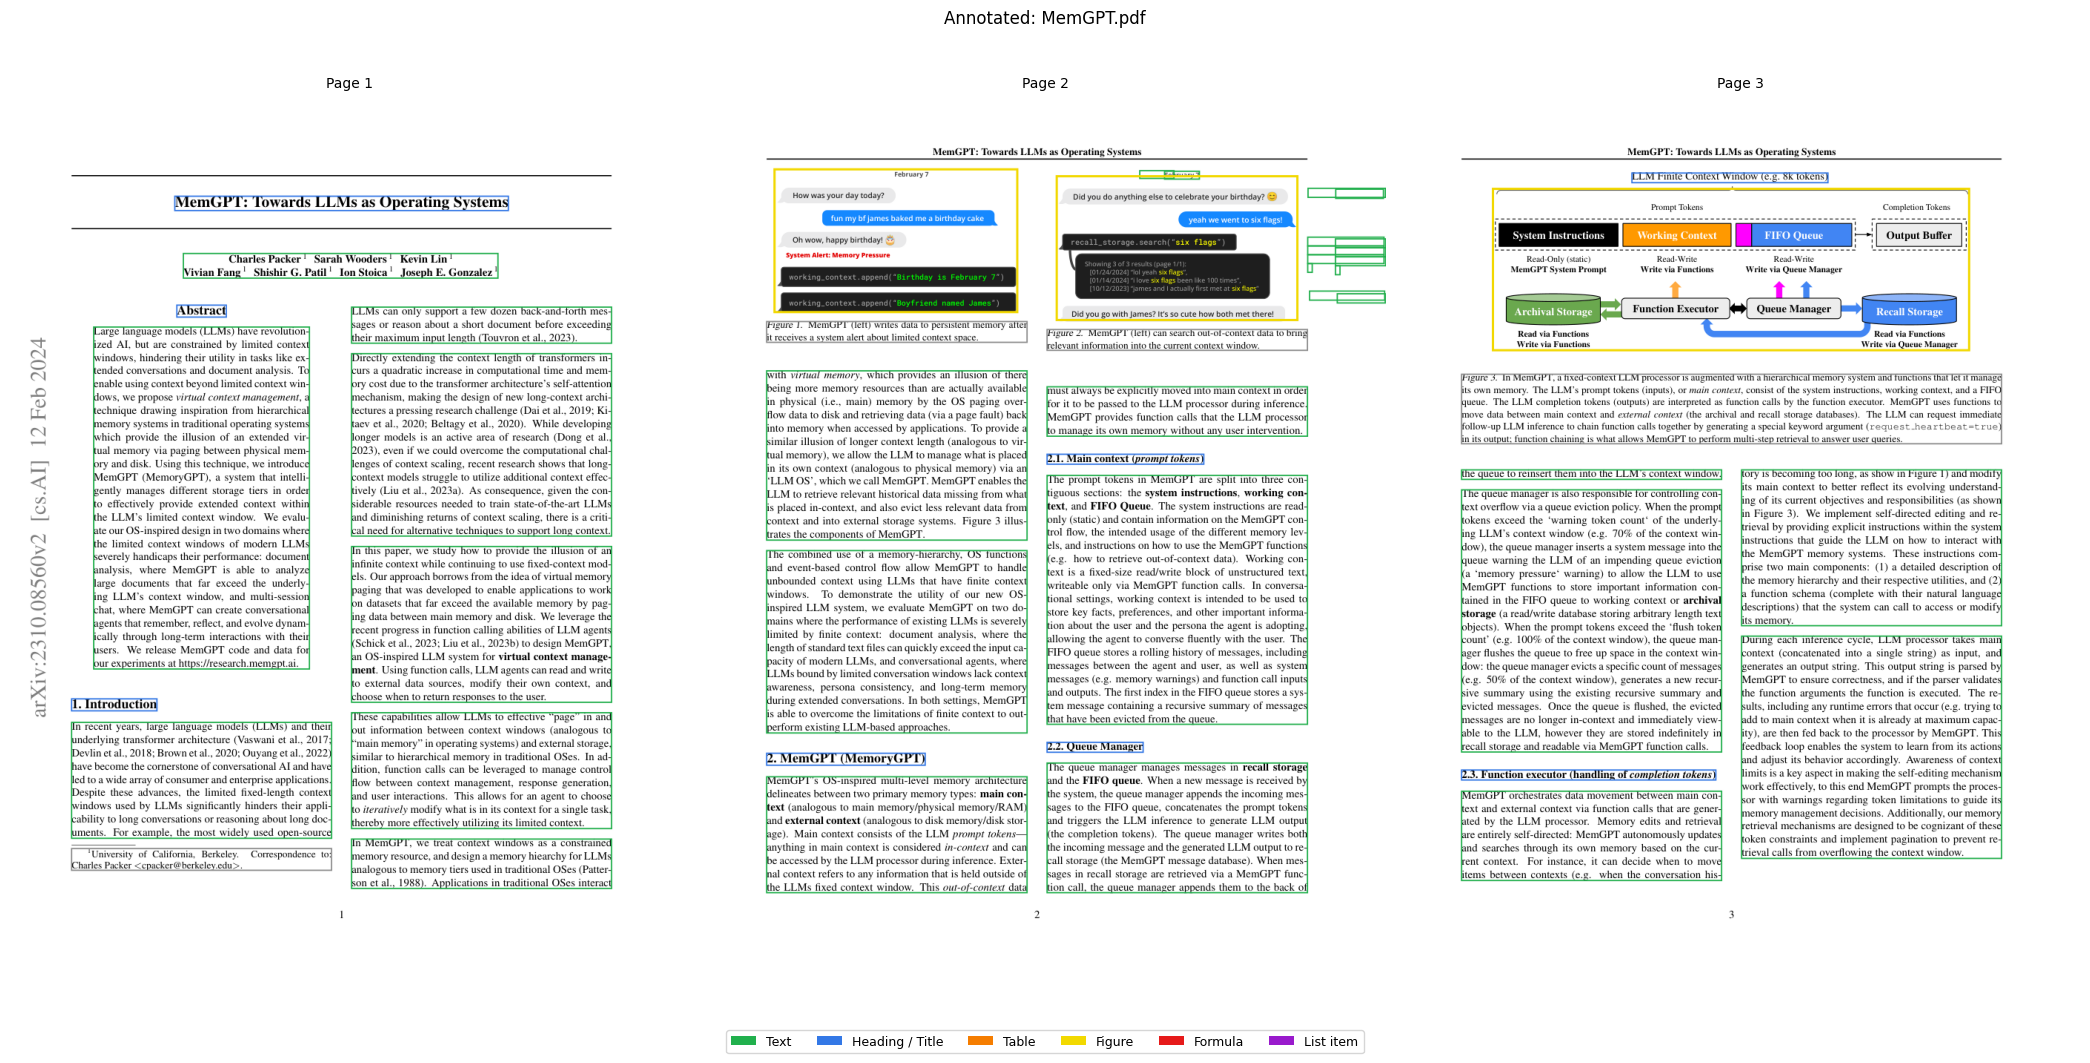

In [36]:
from PIL import Image
import io

# Preview the first N pages of the annotated PDF inline
PREVIEW_PAGES = 3
ZOOM = 1.5          # render resolution multiplier

pdf_preview = fitz.open(str(output_pdf))
mat = fitz.Matrix(ZOOM, ZOOM)

n_pages = min(PREVIEW_PAGES, len(pdf_preview))
fig, axes = plt.subplots(1, n_pages, figsize=(7 * n_pages, 10))
if n_pages == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    pix = pdf_preview[idx].get_pixmap(matrix=mat)
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    ax.imshow(img)
    ax.set_title(f"Page {idx + 1}", fontsize=10)
    ax.axis("off")

pdf_preview.close()

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=(0.13, 0.69, 0.30), label="Text"),
    Patch(facecolor=(0.20, 0.47, 0.90), label="Heading / Title"),
    Patch(facecolor=(0.96, 0.49, 0.00), label="Table"),
    Patch(facecolor=(0.95, 0.85, 0.00), label="Figure"),
    Patch(facecolor=(0.90, 0.10, 0.10), label="Formula"),
    Patch(facecolor=(0.60, 0.10, 0.80), label="List item"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.suptitle(f"Annotated: {PDF_PATH.name}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
